## Semivariograms & Kriging — the Meuse dataset

**Companion to deck `05-spatial-dependence` (Part 2 — Measurements, Point data).**

This notebook shows, step by step, how to:
1. Load the classic **Meuse** dataset (keep `x`, `y`, heavy metals like `zinc`).
2. Turn it into a **GeoDataFrame** and confirm a **metric CRS**.
3. Run a **global spatial autocorrelation test** (Moran's I) on a target metal (e.g., zinc).
4. Build and interpret a **semivariogram** with **SciKit-GStat**.
5. Create **permutation envelopes** for the experimental variogram (is structure beyond random?).
6. **Cross-validate** the variogram/kriging against a non-spatial baseline.
7. **Interpolate** concentrations across the study area via **Ordinary Kriging**.

> Dataset: `meuse.csv` with coordinates `x`, `y` (meters; RD New, EPSG:28992) and variables like `zinc`, `lead`, `copper`, `cadmium`, `elev`, `dist`, etc.  
> Source: https://github.com/filipkral/meuse/tree/master

## Meuse data dictionary (selected fields)

- x, y (meters): Dutch RD New projected coordinates (EPSG:28992)
- zinc (mg/kg, ppm): zinc concentration in topsoil
- lead (mg/kg, ppm): lead concentration in topsoil
- copper (mg/kg, ppm): copper concentration in topsoil
- cadmium (mg/kg, ppm): cadmium concentration in topsoil
- elev (m): elevation
- dist (m): distance to River Meuse
- om (%): organic matter fraction

Source: Meuse dataset (see repository link above). Units reflect standard geochemical reporting.

### Recap: Semivariance and the empirical variogram

Semivariance at lag $h$ measures how different two locations tend to be when they are about distance $h$ apart. A compact, memory-friendly way to say this:

- Pick many pairs of locations that are about distance $h$ apart.
- For each pair compute the difference in the measured value, square it, and then average those squared differences across pairs.
- Semivariance is half of that average.

In symbols (empirical semivariogram):

$$
\hat{\gamma}(h) = \frac{1}{2 |N(h)|} \sum_{(i,j) \in N(h)} \left[z(s_i) - z(s_j)\right]^2
$$

Here $N(h)$ is the set of sample pairs whose separation is approximately $h$ (within a tolerance). Note: we average squared differences, then divide by two.

Why the "half"? For a stationary process the variance of the difference between two points equals twice the process variance minus twice the covariance at lag $h$:

$$
\mathrm{Var}[Z(s+h)-Z(s)] = 2(\sigma^2 - \mathrm{Cov}(h))
$$

Dividing by 2 gives the semivariance $\gamma(h) = \sigma^2 - \mathrm{Cov}(h) = \sigma^2 (1 - \rho(h))$, which ties semivariance directly to correlation $\rho(h)$.

**Intuition and quick implications**

- Small $h$: nearby points tend to be similar $\rightarrow$ small squared differences $\rightarrow$ small semivariance.
- Large $h$: similarity fades $\rightarrow$ semivariance grows and (for large $h$) approaches the process variance (the sill).
- Nugget (value near $h \approx 0$): any nonzero intercept reflects measurement error and/or micro-scale variability (structure that exists at scales smaller than your sampling resolution).

Practical note: we rarely have pairs at exactly $h = 0$, so the nugget is an estimated intercept obtained when you fit a theoretical model to the empirical points (see below). The empirical points are computed from binned distances, then a parametric model (spherical/exponential/gaussian/Matern) is fit to those points and returns nugget, sill and range.

### Nugget estimation, and best practices (short)

**Nugget — intuitive and computational**

- Intuition: the nugget is the "noise floor" of your data — measurement error + micro-scale heterogeneity.
- Computationally: you estimate the nugget by fitting a theoretical variogram model to the empirical semivariogram points. The model intercept at $h = 0$ is the nugget estimate.

**Best practices**

- Choose sensible lag bins (enough pairs per bin); avoid bins with very few pairs.
- Visually inspect empirical points near the origin to see evidence of a nugget.
- Fit more than one model family and compare; use cross-validation diagnostics (kriging CV) to check model choice.
- If your spatial extent is small relative to the true correlation range, you may never reach the sill; interpret parameters cautiously.

In [1]:
# Required libraries for spatial analysis and geostatistics
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from shapely.geometry import Point, Polygon
from libpysal.weights import KNN
from esda.moran import Moran
import gstools as gs
from scipy.spatial.distance import pdist
import skgstat as skg


# Use inline matplotlib backend for notebook visualization
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


## 1) Load & inspect the Meuse data

We select core fields and choose `zinc` as the working response (you can switch to `lead`, `copper`, etc.). Coordinates `x`, `y` are already in meters (Dutch RD New).

In [2]:
# Path to meuse dataset (adjust if stored elsewhere)
CSV_PATH = "data/meuse/meuse.csv"  # expectation: columns x,y,zinc,lead,copper,cadmium,elev,dist,om

df = pd.read_csv(CSV_PATH)
expected_cols = {"x","y","zinc"}
missing = expected_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Keep essential columns (can extend as needed)
cols_keep = [c for c in ["x","y","zinc","lead","copper","cadmium","elev","dist","om"] if c in df.columns]
df = df[cols_keep].copy()
df.head()

,x,y,zinc,lead,copper,cadmium,elev,dist,om
0,181072,333611,1022,299,85,11.7,7.909,0.001358,13.6
1,181025,333558,1141,277,81,8.6,6.983,0.012224,14.0
2,181165,333537,640,199,68,6.5,7.800,0.103029,13.0
3,181298,333484,257,116,81,2.6,7.655,0.190094,8.0
4,181307,333330,269,117,48,2.8,7.480,0.277090,8.7



## 2) Basic cleaning & response setup

Meuse metal concentrations are already numeric. We will:
- Drop rows with missing coordinates or target values.
- Optionally log-transform `zinc` to reduce skew (common in geochemistry); if you do, apply the transform explicitly before running the variogram/kriging cells.

In [3]:
# Target variable (easily switch to 'lead','copper','cadmium')
TARGET = 'zinc'
assert TARGET in df.columns, f"Target {TARGET} not found."

# Drop missing
df = df.dropna(subset=["x","y",TARGET]).copy()

# Optionally log-transform the target: set LOG_TRANSFORM = True to apply a natural log to the target.
# We save an untransformed copy in case you need it for back-transformation or diagnostics.
LOG_TRANSFORM = True  # set to False to keep original scale
if LOG_TRANSFORM:
    df[f"{TARGET}_orig"] = df[TARGET]  # keep original values
    # Clip small/zero values to avoid -inf on log; choose a small positive lower bound
    lower = 1e-6
    df[TARGET] = np.log(df[TARGET].clip(lower=lower))
    print(f"Applied natural log transform to target (saved original in {TARGET}_orig).")

print("Rows after cleaning:", len(df))
df.describe()[[TARGET]]

Applied natural log transform to target (saved original in zinc_orig).
Rows after cleaning: 155


,zinc
count,155.000000
mean,5.885776
std,0.721881
min,4.727388
25%,5.288267
50%,5.786897
75%,6.513969
max,7.516977



## 3) GeoDataFrame & CRS

Meuse coordinates (`x`,`y`) are already in meters (Amersfoort / RD New, EPSG:28992). We build a GeoDataFrame and verify projection.

In [4]:
# Construct GeoDataFrame (coordinates already metric)
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["x"], df["y"]), crs="EPSG:28992")

coords = np.column_stack([gdf.geometry.x, gdf.geometry.y]).astype("float64")
values = gdf[TARGET].to_numpy(dtype="float64")

print("CRS:", gdf.crs)
print("Coordinate sample (m):", coords[:3])
print("Value sample:", values[:3])

CRS: EPSG:28992
Coordinate sample (m): [[181072. 333611.]
 [181025. 333558.]
 [181165. 333537.]]
Value sample: [6.92951677 7.03966035 6.46146818]



## 4) Global spatial autocorrelation: Moran's I

We build a k-nearest neighbors graph (k=8) and test spatial autocorrelation for the target metal.

<Axes: xlabel='x', ylabel='y'>

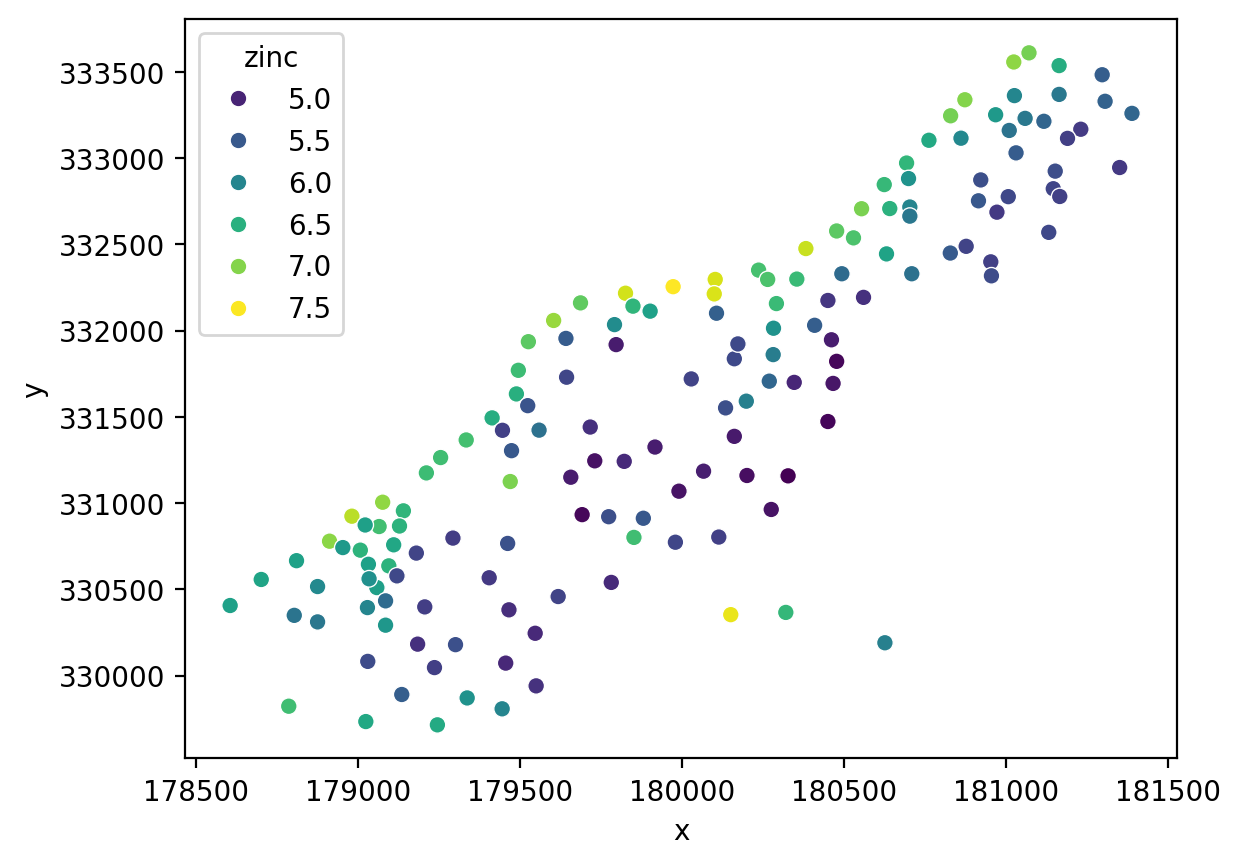

In [5]:
sns.scatterplot(data=gdf, x='x', y='y', hue=TARGET, palette='viridis')

In [6]:

# Build a KNN weights matrix (ensure graph is connected by tuning k if needed)
k = 8
w = KNN.from_array(coords, k=k)
w.transform = "r"  # row-standardize weights

mi = Moran(values, w, permutations=999)
print(f"Moran's I = {mi.I:.4f}   p-value = {mi.p_sim:.4f}   (k={k})")


Moran's I = 0.4896   p-value = 0.0010   (k=8)



**Interpretation**  
- Significant positive I → clustered similar concentrations (e.g., elevated zinc zones).  
- Non-significant → no global spatial autocorrelation at the chosen neighbor scale.  
- Negative (rare here) → spatial repulsion / checkerboard pattern.


## 5) Semivariogram

We examine how semivariance grows with distance; fit a model for kriging.

In [7]:
n_lags = 16

# Build variogram
V = skg.Variogram(
    coordinates=coords,
    values=values,
    model='gaussian',
    n_lags=n_lags,
    maxlag='median',
    use_nugget=True,
    estimator='cressie'
 )

print("Variogram built:", V.model.__name__, "n_lags=", V.n_lags, "maxlag=", V.maxlag)

Variogram built: gaussian n_lags= 16 maxlag= 1372.6660191029719


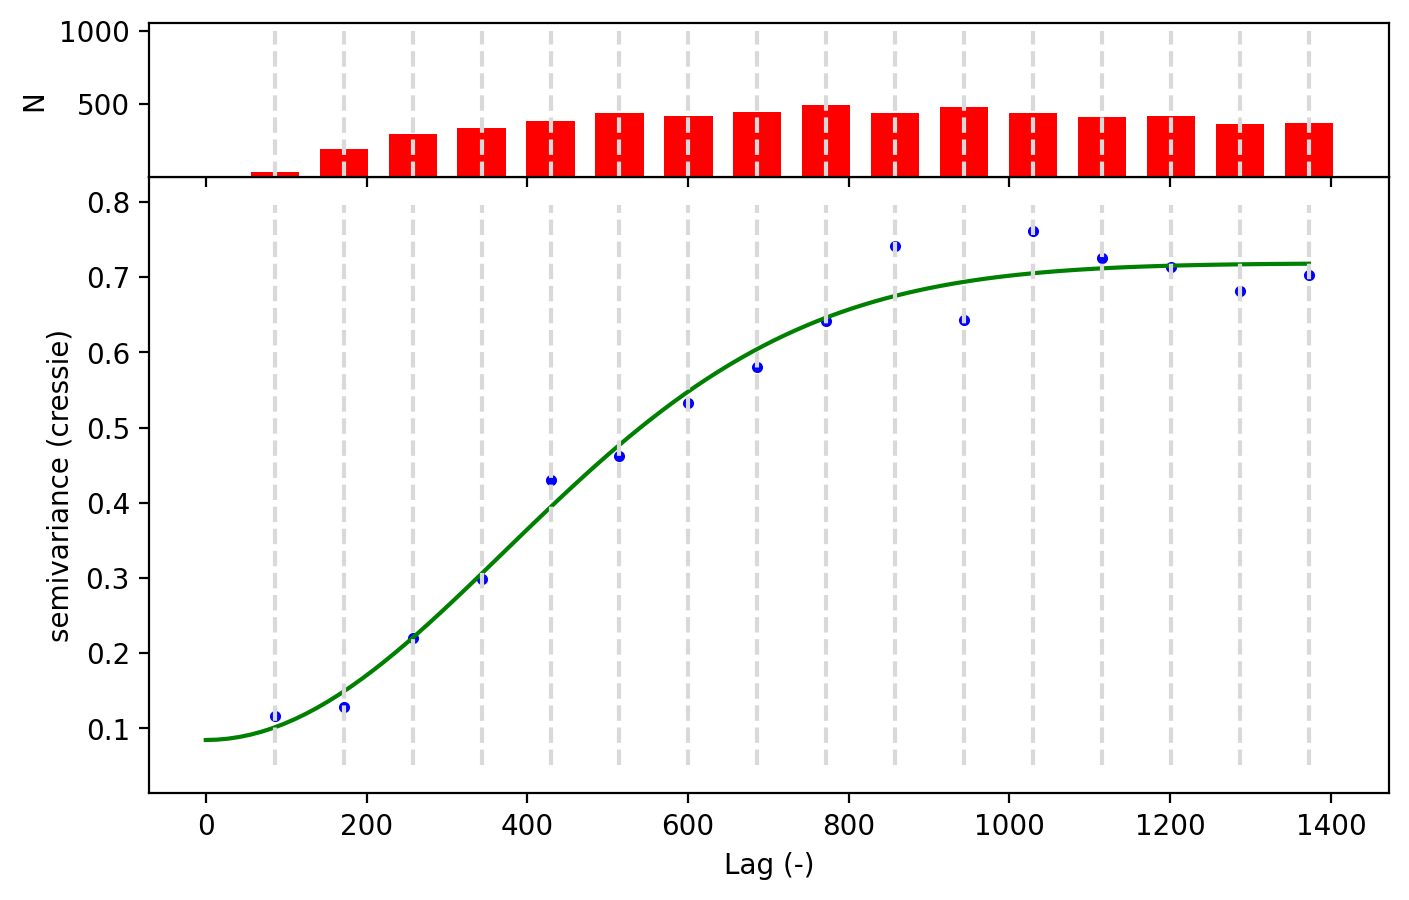

In [8]:
_plot = V.plot()

In [9]:
params = V.describe()
params

{'model': 'gaussian',
 'estimator': 'cressie',
 'dist_func': 'euclidean',
 'normalized_effective_range': np.float64(1438509.808750984),
 'normalized_sill': np.float64(0.48297041802202406),
 'normalized_nugget': np.float64(0.0643836205805433),
 'effective_range': np.float64(1047.9678149904523),
 'sill': np.float64(0.6341332954688785),
 'nugget': np.float64(0.0845347788797616),
 'params': {'estimator': 'cressie',
  'model': 'gaussian',
  'dist_func': 'euclidean',
  'bin_func': 'even',
  'normalize': False,
  'fit_method': 'trf',
  'fit_sigma': None,
  'use_nugget': True,
  'maxlag': np.float64(1372.6660191029719),
  'n_lags': 16,
  'verbose': False},
 'kwargs': {}}

In [10]:
h = V.bins
expv = V.experimental

fit_fn = V.fitted_model
y_fit = fit_fn(h)

# NOTE: skgstat reports the PARTIAL sill (structured variance ABOVE the nugget).
# The plateau the curve actually reaches is the TOTAL sill = nugget + partial sill.
nugget       = params["nugget"]
partial_sill = params["sill"]
sill         = nugget + partial_sill        # total sill = the plateau
eff_range    = params["effective_range"]

print({"nugget": round(nugget, 3), "partial_sill": round(partial_sill, 3),
       "sill (total)": round(sill, 3), "range": round(eff_range, 1)})
print("nugget / total sill =", round(nugget / sill, 3))

{'nugget': np.float64(0.085), 'partial_sill': np.float64(0.634), 'sill (total)': np.float64(0.719), 'range': np.float64(1048.0)}
nugget / total sill = 0.118


**How to read this**
- **Nugget**: micro-scale variability + measurement noise (field sampling and lab).
- **Partial sill**: the *structured* variance — how far the curve climbs **above** the nugget. This is what `skgstat` reports as `sill`.
- **Sill (total)** = nugget + partial sill: the plateau, i.e. total semivariance once spatial correlation vanishes.
- **Range**: distance where spatial influence fades; beyond it, additional distance adds little dissimilarity.

Reading the fitted parameters above (log-zinc, gaussian model):
- **Nugget ≈ 0.08** → small micro-scale noise.
- **Partial sill ≈ 0.63** → the spatially *structured* variance (what `skgstat` calls `sill`).
- **Sill (total) ≈ 0.72** = nugget + partial sill → the plateau the curve levels off at; compare the sample variance of log-zinc (≈ 0.52).
- **Range ≈ 1048 m** → spatial dependence extends roughly 1 km; beyond that, points are effectively uncorrelated.

**Units matter.** Semivariance is in **squared natural-log units**, not mg/kg. At the plateau the
average squared difference between two uncorrelated locations is $2\times0.72\approx1.44$, a typical
gap of $\sqrt{1.44}\approx1.2$ log-units — i.e. a factor of $e^{1.2}\approx$ **3× in zinc concentration**.

Nugget-to-sill ratio and practical meaning:
- Ratio = nugget / **total** sill ≈ 0.08 / 0.72 ≈ **0.12**; values < 0.25 indicate **strong spatial dependence** (good for kriging) — about **88%** of the variance is spatially structured.

**Lesson —** the variogram turns a cloud of points into three operational numbers — nugget (noise floor), sill (total variance), range (spatial horizon) — and their ratio tells you at a glance whether kriging is worth it.

> Note: We use a robust estimator (`cressie`) with 16 lags and `maxlag='median'` to emphasize short-range structure; tweak for different targets.

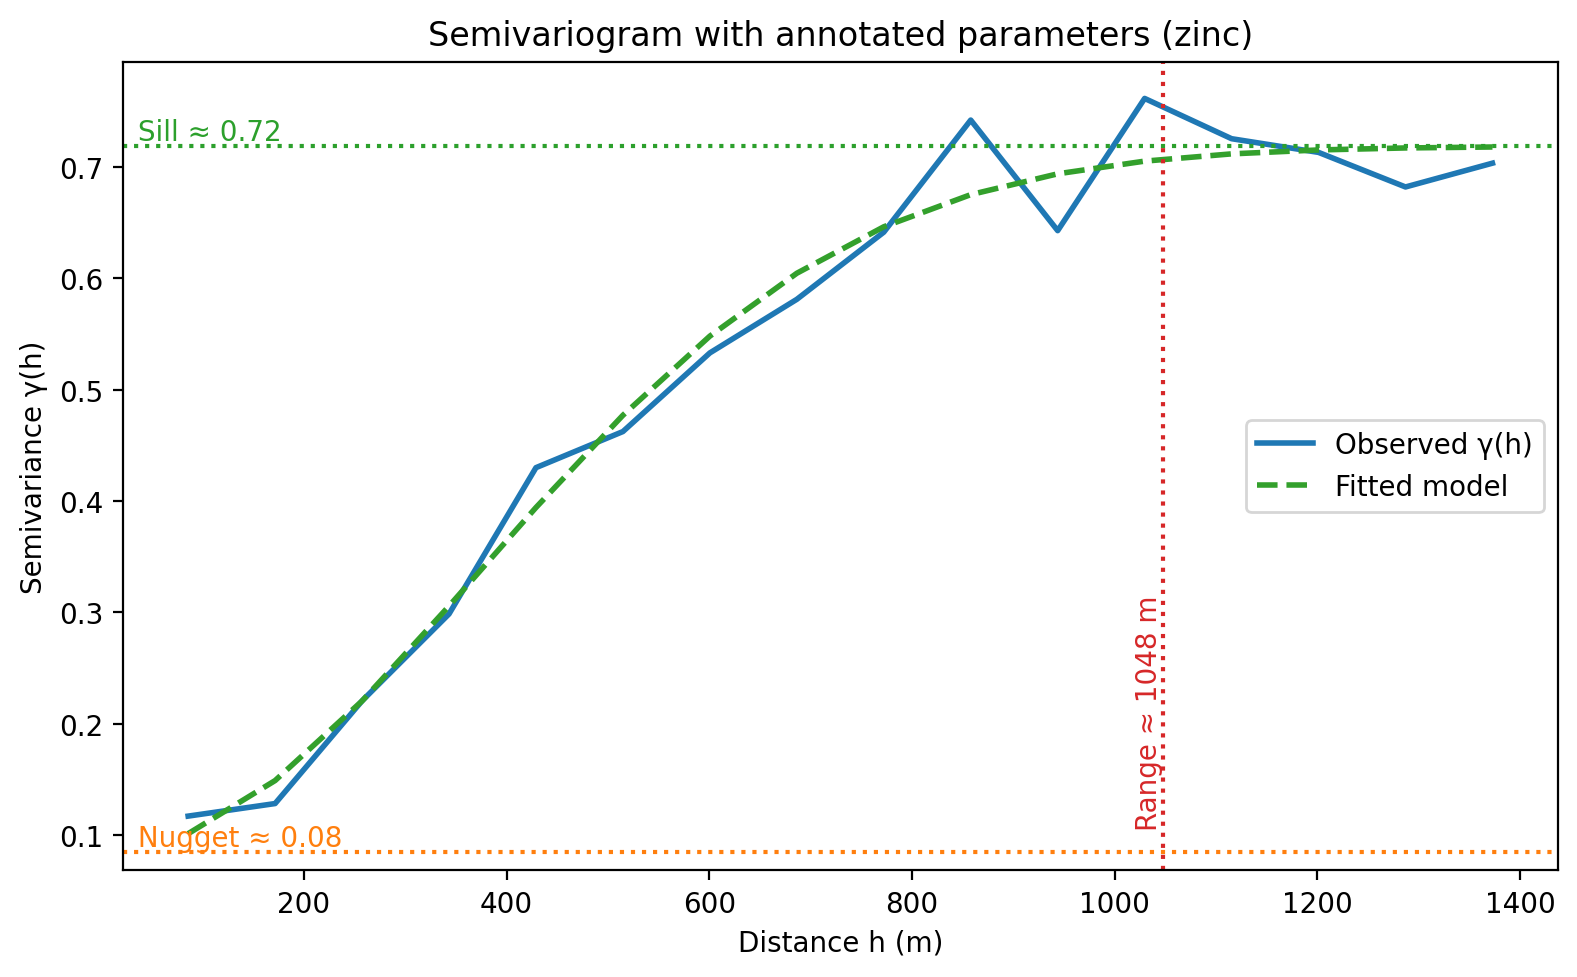

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(h, expv, label='Observed γ(h)', lw=2, color='#1f78b4')
ax.plot(h, y_fit, label='Fitted model', ls='--', lw=2, color='#33a02c')
ax.axhline(nugget, color='tab:orange', ls=':', lw=1.5)
ax.text(h.max()*0.02, nugget, f" Nugget ≈ {nugget:.2f}", va='bottom', color='tab:orange')
ax.axhline(sill, color='tab:green', ls=':', lw=1.5)
ax.text(h.max()*0.02, sill, f" Sill ≈ {sill:.2f}", va='bottom', color='tab:green')
ax.axvline(eff_range, color='tab:red', ls=':', lw=1.5)
y0, y1 = ax.get_ylim()
ax.text(eff_range, y0 + 0.05*(y1-y0), f"Range ≈ {eff_range:.0f} m", rotation=90, va='bottom', ha='right', color='tab:red')
ax.set_xlabel('Distance h (m)')
ax.set_ylabel('Semivariance γ(h)')
ax.set_title(f'Semivariogram with annotated parameters ({TARGET})')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()



### Compare variogram models by RMSE


> Model selection note: prefer CV error (prediction-focused) over pure variogram RMSE; confirm that chosen configuration yields early-lag structure consistent with envelopes.

In [12]:
candidates = ["spherical", "exponential", "gaussian", "stable", "matern"]
scores = {}
for m in candidates:
    
    V.set_model(m)
    V.fit(force=True)
    
    scores[m] = float(V.rmse)

# The loop above leaves V fitted with the LAST candidate; restore the working model
V.set_model("gaussian")
V.fit(force=True)

scores


{'spherical': 0.03266350024319307,
 'exponential': 0.05990255027431278,
 'gaussian': 0.030524630277367112,
 'stable': 0.030524630277281865,
 'matern': 0.030818908222498158}


## 6) Structure beyond random? Permutation envelope

Shuffle target values across locations to form a null (no spatial structure) and compare the experimental semivariogram.

In [13]:
# Build permutation envelope (compute only)
from tqdm import trange
import numpy as np

n_sim = 99  # 99 for classroom speed; use 499/999 for publication-grade envelopes
sim_exp = []

for _ in trange(n_sim, desc="Permutations"):
    Vp = skg.Variogram(
        coordinates=coords,
        values=np.random.permutation(values),
        n_lags=V.n_lags,
        maxlag=V.maxlag,
        use_nugget=True,
        estimator=V.estimator
    )
    sim_exp.append(Vp.experimental)

sim_exp = np.vstack(sim_exp)
lo = np.percentile(sim_exp, 2.5, axis=0)
hi = np.percentile(sim_exp, 97.5, axis=0)
h = V.bins
obs = V.experimental
print("Envelope computed.")

Permutations:   0%|          | 0/99 [00:00<?, ?it/s]

Permutations:  34%|███▍      | 34/99 [00:00<00:00, 330.05it/s]

Permutations:  70%|██████▉   | 69/99 [00:00<00:00, 335.61it/s]

Permutations: 100%|██████████| 99/99 [00:00<00:00, 339.36it/s]

Envelope computed.



**Interpretation**  
- Observed below lower band at short lags → nearby concentrations more similar than random (positive structure).
- Within band → cannot reject random allocation at those distances.
- Above band (rare here) → local repulsion / sharp contrasts.


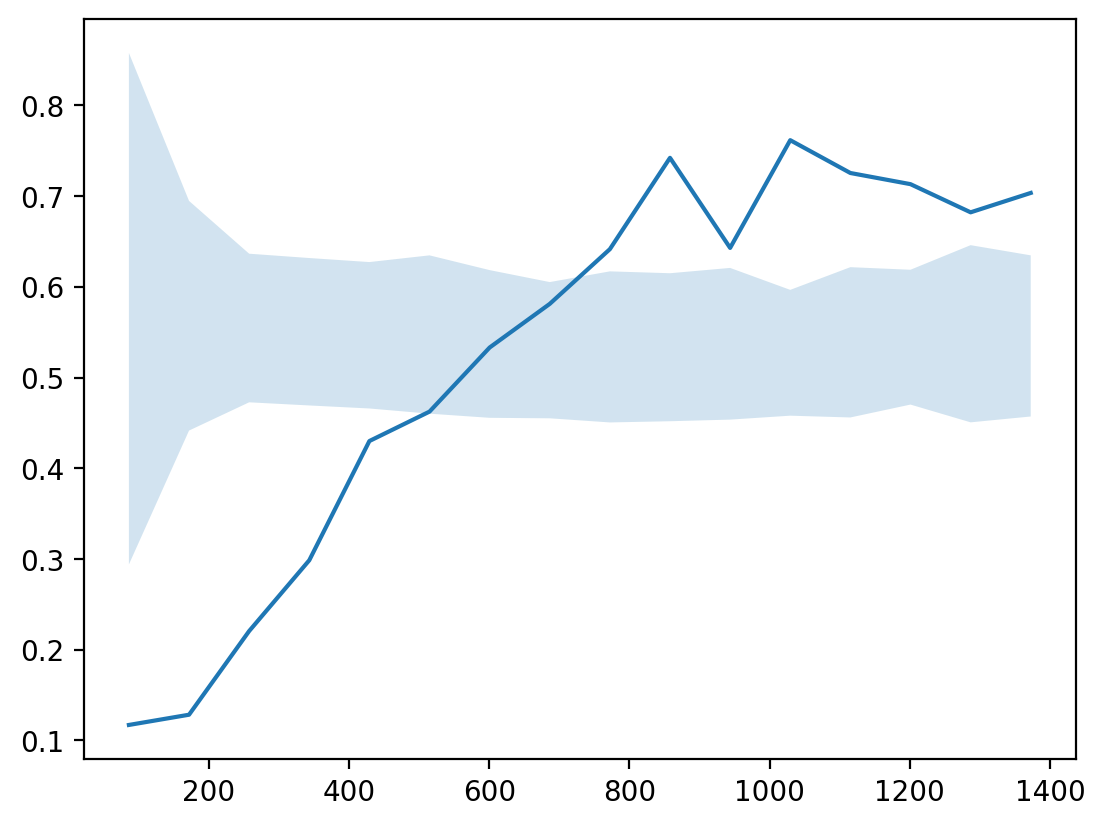

In [14]:
# Plot variogram with permutation envelope
plt.plot(h, obs)
plt.fill_between(h, lo, hi, alpha=0.2)


## 7) Predictive value: jackknife cross-validation vs global mean

In [15]:

# Baseline: always predict the global mean
ybar = values.mean()
baseline_rmse = np.sqrt(np.mean((values - ybar)**2))

# SciKit-GStat jackknife CV (uses kriging internally)
cv_rmse = V.cross_validate(method='jacknife', metric='rmse')

print(f"Baseline RMSE: {baseline_rmse:.3f}")
print(f"Kriging CV RMSE: {cv_rmse:.3f}")
improve = (baseline_rmse - cv_rmse) / baseline_rmse * 100
print(f"Relative improvement: {improve:.1f}%")


Baseline RMSE: 0.720
Kriging CV RMSE: 0.391
Relative improvement: 45.7%


Kriging CV RMSE (0.39) is well below the global-mean baseline (0.72) — a ~46% error
reduction — so the spatial dependence the variogram detected is also *predictively*
useful, not merely statistically significant.

**Lesson —** validate the variogram by prediction, not just by eye: if spatially-aware
cross-validation beats a naive mean, the fitted range and sill are earning their keep.

## 8) Ordinary Kriging: interpolated concentration surface

So far the variogram has been a *description*: it told us that log-zinc values 100 m apart are
usually similar, and that beyond ~1 km they are effectively unrelated. Section 7 showed this
description is also *predictive*. Now we cash it in: we predict zinc at the locations where nobody
sampled, and we produce a continuous map.

The method is **Ordinary Kriging (OK)**. This section builds it from scratch — one location, by
hand, with the matrices printed — before calling any library.

### 8.1) What is kriging? (start here if the word is new)

We have 155 soil samples. We want zinc at some location $x_0$ where nobody dug. Every method for
this problem — every single one — answers with a **weighted average of the observations**:

$$\hat{Z}(x_0) \;=\; \sum_{i=1}^{n} w_i \, Z(x_i)$$

That is the whole game. The only question is **where the weights $w_i$ come from**:

| Method | Weights come from | Problem |
|---|---|---|
| Global mean | $w_i = 1/n$ — every sample counts the same | Ignores that near samples are more informative |
| Nearest neighbour | $w = 1$ for the closest, $0$ for all others | Throws away all other data; blocky map |
| **IDW** (inverse distance) | $w_i \propto 1/d_i^{\,p}$ — a formula *you* pick | Where did $p=2$ come from? Nowhere. You guessed |
| **Kriging** | The **fitted variogram** — i.e. from the data itself | Needs a variogram (we already have one) |

**Kriging is the interpolator that asks the data how far correlation reaches, and weights
accordingly.** You do not choose a decay exponent; the range, sill and nugget you fitted in §5
*are* the decay law, estimated from the observed pairs.

Two more properties make it "Ordinary" kriging specifically — and they are what the math below
enforces:

1. **Unbiased**: the weights are forced to sum to 1, $\sum_i w_i = 1$. So if all neighbours read
   6.5, the prediction reads 6.5 — no systematic drift up or down. ("Ordinary" = the mean is
   unknown but assumed constant over the neighbourhood; this constraint is how we avoid having to
   know it.)
2. **Minimum variance**: among all unbiased weighted averages, kriging picks the weights with the
   smallest expected squared error — and the variogram is what lets us compute that error before
   knowing the truth.

Together: kriging is the **B.L.U.E.** — Best (minimum variance) Linear (a weighted average)
Unbiased (weights sum to 1) Estimator. And a bonus no other interpolator above gives you: with the
prediction it returns a **kriging variance**, an uncertainty value at every location.

### 8.2) The one ingredient kriging needs: $\gamma(h)$ as a function

Everything below calls the fitted variogram as a *function of distance*: hand it a distance in
metres, it returns the expected semivariance — how different two points that far apart tend to be.

`skgstat` gives this as `V.fitted_model`, but that function is compiled for scalars, so we wrap it
once with `np.vectorize` to feed it whole distance matrices.

In [16]:
# The fitted variogram, usable as gamma(h) on arrays of distances
_scalar_model = V.fitted_model
gamma = np.vectorize(lambda h: float(_scalar_model(float(h))))

# Read the fitted parameters back out (skgstat order: range, partial sill, nugget)
rng, psill, nug = V.parameters
print(f"range = {rng:.0f} m | partial sill = {psill:.3f} | nugget = {nug:.3f}")

probe = np.array([0.0, 50.0, 200.0, 500.0, rng, 2 * rng])
for d, gv in zip(probe, gamma(probe)):
    print(f"gamma({d:7.0f} m) = {gv:.3f}")

range = 1048 m | partial sill = 0.634 | nugget = 0.085
gamma(      0 m) = 0.085
gamma(     50 m) = 0.090
gamma(    200 m) = 0.171
gamma(    500 m) = 0.464
gamma(   1048 m) = 0.707
gamma(   2096 m) = 0.719


Read that table as the model's own summary of the spatial structure:

- $\gamma(0) \approx$ the **nugget** — even two samples at (almost) the same spot differ a bit:
  lab error plus micro-scale variation.
- $\gamma(50\text{ m})$ is still tiny → samples 50 m apart are nearly interchangeable → whichever
  one is near $x_0$ deserves a **large** weight.
- $\gamma$ climbs to the **sill** near the range (~1048 m) → beyond that, a sample carries no
  information about $x_0$ that the local mean does not already carry → **near-zero** weight.

Kriging is nothing more than this table, applied consistently.

### 8.3) Step 1 — pick a target location and its neighbours

Take one unsampled spot in the middle of the field. We keep only the $k = 6$ nearest observations:
past the range, extra samples add nothing but a bigger matrix. (Production code searches "all
points within the range, capped at `max_points`" — same idea.)

In [17]:
x0 = np.array([179000.0, 331000.0])   # the unsampled location we want to predict
k = 6                                 # neighbourhood size

d0 = np.linalg.norm(coords - x0, axis=1)     # distance from every sample to x0
nbr = np.argsort(d0)[:k]                     # indices of the k nearest samples
P, z_nbr = coords[nbr], values[nbr]

pd.DataFrame({
    "neighbour": range(1, k + 1),
    "distance to x0 (m)": d0[nbr].round(1),
    f"observed {TARGET} (log)": z_nbr.round(3),
})

,neighbour,distance to x0 (m),observed zinc (log)
0,1,76.2,7.057
1,2,78.3,7.232
2,3,128.9,6.301
3,4,147.1,6.555
4,5,150.7,6.676
5,6,184.6,6.516


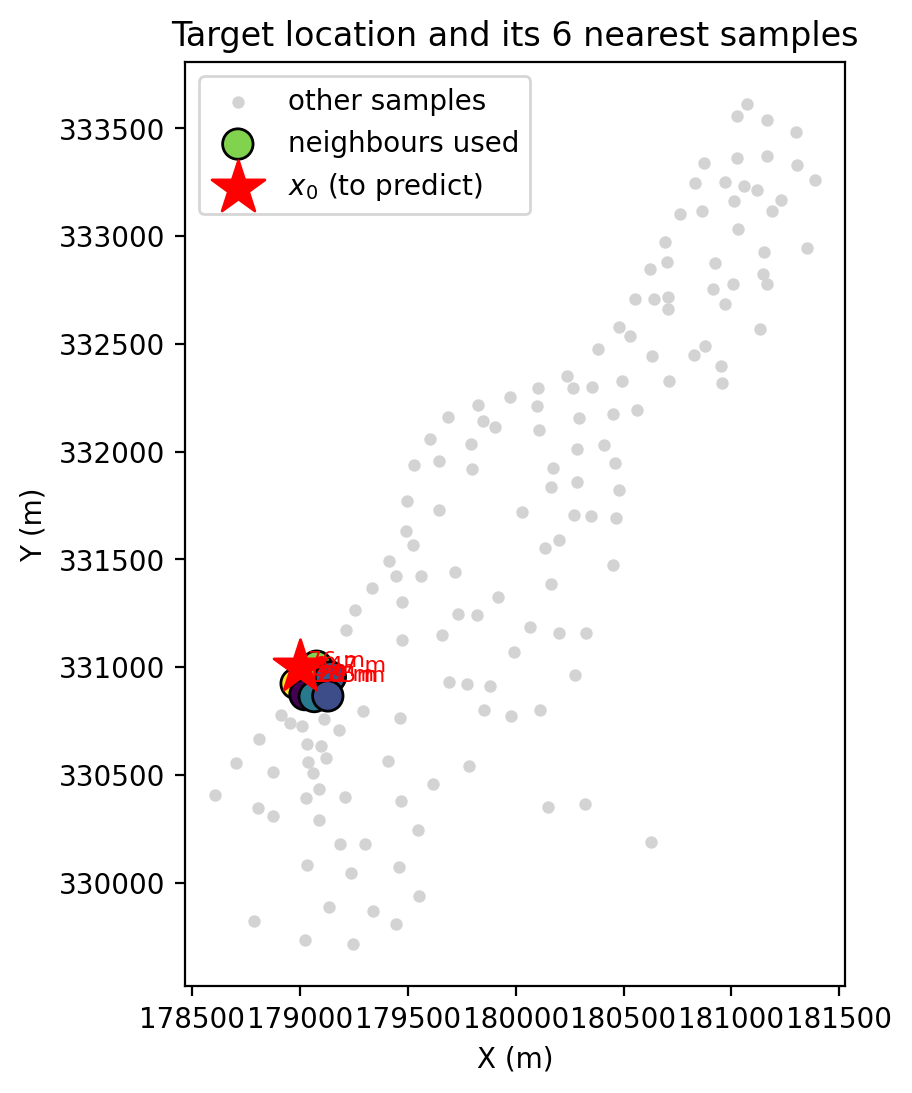

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
gdf.plot(ax=ax, color="lightgrey", markersize=12, label="other samples")
ax.scatter(P[:, 0], P[:, 1], c=z_nbr, cmap="viridis", s=120,
           edgecolor="k", zorder=3, label="neighbours used")
ax.scatter(*x0, marker="*", s=400, color="red", zorder=4, label="$x_0$ (to predict)")
for (px, py), dd in zip(P, d0[nbr]):
    ax.plot([x0[0], px], [x0[1], py], color="red", lw=0.8, ls=":", zorder=2)
    ax.annotate(f"{dd:.0f} m", ((x0[0] + px) / 2, (x0[1] + py) / 2), fontsize=8, color="red")
ax.set_title("Target location and its 6 nearest samples")
ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_aspect("equal"); ax.legend()
plt.show()

### 8.4) Step 2 — write down the kriging system

We want the weights that minimise the prediction error, subject to $\sum_i w_i = 1$. Doing that
minimisation (Lagrange multipliers — the derivation is standard, we take the result) gives a linear
system of $k+1$ equations in $k+1$ unknowns: the $k$ weights, plus one extra unknown $\mu$, the
**Lagrange multiplier** that enforces the unbiasedness constraint.

$$
\underbrace{
\begin{bmatrix}
\gamma_{11} & \cdots & \gamma_{1k} & 1 \\
\vdots      & \ddots & \vdots      & \vdots \\
\gamma_{k1} & \cdots & \gamma_{kk} & 1 \\
1           & \cdots & 1           & 0
\end{bmatrix}}_{\mathbf{A}\;:\;\text{how redundant are the neighbours?}}
\underbrace{
\begin{bmatrix} w_1 \\ \vdots \\ w_k \\ \mu \end{bmatrix}}_{\text{unknowns}}
=
\underbrace{
\begin{bmatrix} \gamma_{10} \\ \vdots \\ \gamma_{k0} \\ 1 \end{bmatrix}}_{\mathbf{b}\;:\;\text{how close is each neighbour to } x_0?}
$$

with $\gamma_{ij} = \gamma\!\left(\lVert x_i - x_j \rVert\right)$ between two **samples**, and
$\gamma_{i0} = \gamma\!\left(\lVert x_i - x_0 \rVert\right)$ between a sample and the **target**.

Read the two sides:

- $\mathbf{b}$ is the **relevance** vector: small $\gamma_{i0}$ = neighbour $i$ is strongly
  correlated with $x_0$ = it should get weight. This is the part IDW imitates.
- $\mathbf{A}$ is the **redundancy** matrix, and it is what IDW has no answer for: it describes how
  much the neighbours duplicate *each other*. Three samples huddled together are almost one sample,
  and $\mathbf{A}$ knows it.
- The last row is literally $w_1 + \cdots + w_k = 1$: the unbiasedness constraint, bolted on as an
  equation.
- The diagonal is $\gamma(0)$ set to **0**, not to the nugget: a sample is trivially identical to
  itself.

In [19]:
from scipy.spatial.distance import cdist

# A: semivariance between every pair of NEIGHBOURS (redundancy), + constraint row/column
A = np.ones((k + 1, k + 1))
A[:k, :k] = gamma(cdist(P, P))
np.fill_diagonal(A, 0.0)      # gamma(0) = 0 on the diagonal: a point equals itself
A[k, k] = 0.0                 # bottom-right corner of the Lagrange block

# b: semivariance between each NEIGHBOUR and the TARGET (relevance), + the "= 1" constraint
b = np.ones(k + 1)
b[:k] = gamma(cdist(P, x0[None, :]).ravel())

labels = [f"n{i+1}" for i in range(k)] + ["mu / constraint"]
print("A — pairwise semivariance among neighbours (redundancy):")
display(pd.DataFrame(A, index=labels, columns=labels).round(3))
print("\nb — semivariance of each neighbour to x0 (relevance):")
display(pd.DataFrame({"gamma(xi, x0)": b}, index=labels).round(3))

A — pairwise semivariance among neighbours (redundancy):


,n1,n2,n3,n4,n5,n6,mu / constraint
n1,0.000,0.120,0.130,0.100,0.129,0.133,1.0
n2,0.120,0.000,0.094,0.142,0.109,0.139,1.0
n3,0.130,0.094,0.000,0.130,0.089,0.110,1.0
n4,0.100,0.142,0.130,0.000,0.116,0.102,1.0
n5,0.129,0.109,0.089,0.116,0.000,0.094,1.0
n6,0.133,0.139,0.110,0.102,0.094,0.000,1.0
mu / constraint,1.000,1.000,1.000,1.000,1.000,1.000,0.0



b — semivariance of each neighbour to x0 (relevance):


,"gamma(xi, x0)"
n1,0.098
n2,0.099
n3,0.122
n4,0.133
n5,0.135
n6,0.159
mu / constraint,1.000


### 8.5) Step 3 — solve it

One `np.linalg.solve` call. Out come the weights and $\mu$; the prediction is the weighted average,
and the kriging variance is

$$\sigma^2(x_0) \;=\; \sum_{i=1}^{k} w_i \, \gamma_{i0} \;+\; \mu .$$

Note what is *not* in that formula: the observed values $Z(x_i)$. **The uncertainty of a kriged map
depends only on the sampling geometry and the variogram, never on the measurements.** You can map
where your survey will be uncertain before collecting a single sample — which is exactly how kriging
gets used to design surveys.

In [20]:
sol = np.linalg.solve(A, b)
w, mu = sol[:k], sol[k]

z_hat = float(w @ z_nbr)                 # prediction: the weighted average
sigma2 = float(w @ b[:k] + mu)           # kriging variance

display(pd.DataFrame({
    "distance (m)": d0[nbr].round(1),
    f"observed {TARGET}": z_nbr.round(3),
    "gamma(xi, x0)": b[:k].round(3),
    "kriging weight": w.round(4),
}, index=[f"n{i+1}" for i in range(k)]))

print(f"sum of weights   = {w.sum():.6f}   (the unbiasedness constraint, satisfied exactly)")
print(f"mu (Lagrange)    = {mu:+.4f}")
print(f"prediction z_hat = {z_hat:.3f}  (log {TARGET})  ->  {np.exp(z_hat):.0f} mg/kg")
print(f"kriging variance = {sigma2:.3f}  ->  sd = {np.sqrt(sigma2):.3f} log units")

,distance (m),observed zinc,"gamma(xi, x0)",kriging weight
n1,76.2,7.057,0.098,0.3780
n2,78.3,7.232,0.099,0.3608
n3,128.9,6.301,0.122,0.1485
n4,147.1,6.555,0.133,0.1237
n5,150.7,6.676,0.135,0.0461
n6,184.6,6.516,0.159,-0.0571


sum of weights   = 1.000000   (the unbiasedness constraint, satisfied exactly)
mu (Lagrange)    = +0.0247
prediction z_hat = 6.959  (log zinc)  ->  1053 mg/kg
kriging variance = 0.129  ->  sd = 0.359 log units


**Read the weight column.** The two samples at ~76 m and ~78 m take ~0.38 and ~0.36 — together
three quarters of the prediction. Weight then falls off fast with distance, and the last neighbour
comes out **slightly negative** (~-0.06).

Negative weights are not a bug. They are kriging **screening**: that far sample sits *behind* a
closer one, which already speaks for that direction; the system uses it to extrapolate the local
gradient rather than to average. (Practical caveat: negative weights can push a prediction outside
the observed range — for strictly positive quantities like concentrations, check for negative
back-transformed values, and constrain the neighbourhood if it bites.)

### 8.6) Step 4 — was it worth it? Compare against the alternatives

Same location, same six neighbours, three different weighting rules.

In [21]:
w_idw = (1 / d0[nbr] ** 2) / np.sum(1 / d0[nbr] ** 2)    # IDW, p = 2
w_mean = np.full(k, 1 / k)                               # plain local average

display(pd.DataFrame({
    "kriging": w.round(3),
    "IDW (p=2)": w_idw.round(3),
    "local mean": w_mean.round(3),
}, index=[f"n{i+1} ({dd:.0f} m)" for i, dd in enumerate(d0[nbr])]))

print(f"kriging      : {z_hat:.3f}")
print(f"IDW (p=2)    : {float(w_idw @ z_nbr):.3f}")
print(f"local mean   : {float(w_mean @ z_nbr):.3f}")
print(f"global mean  : {values.mean():.3f}   <- the §7 baseline, ignores location entirely")

,kriging,IDW (p=2),local mean
n1 (76 m),0.378,0.335,0.167
n2 (78 m),0.361,0.316,0.167
n3 (129 m),0.149,0.117,0.167
n4 (147 m),0.124,0.090,0.167
n5 (151 m),0.046,0.085,0.167
n6 (185 m),-0.057,0.057,0.167


kriging      : 6.959
IDW (p=2)    : 6.916
local mean   : 6.723
global mean  : 5.886   <- the §7 baseline, ignores location entirely


The three local estimates land close together here — with dense, evenly spread samples they should.
The difference is *why*: IDW's numbers come from an exponent someone typed, kriging's come from the
1048 m range and 0.08 nugget the data reported. Change the sampling design or the phenomenon and
IDW keeps typing 2 while kriging adapts. And only kriging returns the $\sigma$ that told us the sd
here is ~0.36 log units.

**Lesson —** any interpolator is a weighted average of neighbours; what distinguishes a good one is
that its weights are estimated from the data's own correlation structure rather than assumed.

### 8.7) Why kriging beats a distance formula: redundancy

$\mathbf{A}$ deserves a demo of its own, because it is the part IDW structurally cannot have.

Set up a textbook configuration: **three samples clustered** 300 m west of the target, **one lone
sample** 300 m east. All four are the same distance from $x_0$. IDW only sees distance, so it gives
all four the same weight — and the west, having three votes, outvotes the east 3:1 purely because a
field crew happened to sample there three times.

In [22]:
P_demo = np.array([[-300.0, 0.0], [-320.0, 30.0], [-310.0, -25.0],   # clustered, west
                   [ 300.0, 0.0]])                                    # isolated, east
x0_demo = np.array([0.0, 0.0])
kd = len(P_demo)

A_d = np.ones((kd + 1, kd + 1))
A_d[:kd, :kd] = gamma(cdist(P_demo, P_demo))
np.fill_diagonal(A_d, 0.0); A_d[kd, kd] = 0.0
b_d = np.ones(kd + 1)
b_d[:kd] = gamma(cdist(P_demo, x0_demo[None, :]).ravel())
w_d = np.linalg.solve(A_d, b_d)[:kd]

d_demo = np.linalg.norm(P_demo - x0_demo, axis=1)
w_d_idw = (1 / d_demo ** 2) / np.sum(1 / d_demo ** 2)

display(pd.DataFrame({
    "distance (m)": d_demo.round(0),
    "kriging": w_d.round(3),
    "IDW (p=2)": w_d_idw.round(3),
}, index=["west (cluster)", "west (cluster)", "west (cluster)", "east (isolated)"]))

print(f"west cluster total -> kriging {w_d[:3].sum():.3f} | IDW {w_d_idw[:3].sum():.3f}")
print(f"east isolated      -> kriging {w_d[3]:.3f} | IDW {w_d_idw[3]:.3f}")

,distance (m),kriging,IDW (p=2)
west (cluster),300.0,0.251,0.263
west (cluster),321.0,0.097,0.229
west (cluster),311.0,0.170,0.245
east (isolated),300.0,0.481,0.263


west cluster total -> kriging 0.519 | IDW 0.737
east isolated      -> kriging 0.481 | IDW 0.263


Kriging splits the west cluster's influence (~0.52 shared three ways) and hands the lone east sample
~0.48 — nearly half the prediction, because it is the only witness for its side of the map. IDW
gives west ~0.74. **Kriging declusters automatically**: $\mathbf{A}$ shows the three western samples
have near-zero semivariance *with each other*, so the system treats them as roughly one sample.

This is why kriging is robust to the sampling designs you actually get — preferential sampling near
roads, repeat visits to convenient sites, a survey doubled up in one corner.

**Lesson —** an interpolator must weigh not only how close each observation is to the target, but
how much the observations duplicate one another; ignoring redundancy lets sampling effort
masquerade as signal.

### 8.8) The variogram *is* the dial: change it, watch the weights move

If the weights come from the variogram, then the variogram's parameters have direct, predictable
consequences. Re-solve the §8.5 system with the *same* six neighbours but deliberately altered
$\gamma(h)$, and the abstract parameters from §5 become concrete behaviour.

In [23]:
from skgstat.models import gaussian

# The fitted Gaussian model, but with parameters we override for the sake of argument
def gamma_with(range_, psill_, nugget_):
    return np.vectorize(lambda h: float(gaussian(float(h), range_, psill_, nugget_)))

# Ordinary Kriging at x0 from neighbours P — the 8.4 system, in one function
def solve_ok(gam, P, x0):
    n = len(P)
    A = np.ones((n + 1, n + 1))
    A[:n, :n] = gam(cdist(P, P)); np.fill_diagonal(A, 0.0); A[n, n] = 0.0
    b = np.ones(n + 1)
    b[:n] = gam(cdist(P, np.asarray(x0)[None, :]).ravel())
    s = np.linalg.solve(A, b)
    return s[:n], float(s[:n] @ b[:n] + s[n])      # weights, kriging variance

scenarios = {
    "fitted (range 1048, nugget 0.08)": gamma_with(rng, psill, nug),
    "pure nugget (no structure)":       gamma_with(rng, 1e-6, psill + nug),
    "short range (150 m)":              gamma_with(150.0, psill, nug),
    "long range (5000 m)":              gamma_with(5000.0, psill, nug),
}

rows = {}
for name, gam in scenarios.items():
    ws, s2 = solve_ok(gam, P, x0)
    rows[name] = list(np.round(ws, 3)) + [round(float(ws @ z_nbr), 3), round(np.sqrt(s2), 3)]

display(pd.DataFrame(
    rows, index=[f"w: n{i+1} ({dd:.0f} m)" for i, dd in enumerate(d0[nbr])] + ["prediction", "sd"]
).T)

,w: n1 (76 m),w: n2 (78 m),w: n3 (129 m),w: n4 (147 m),w: n5 (151 m),w: n6 (185 m),prediction,sd
"fitted (range 1048, nugget 0.08)",0.378,0.361,0.149,0.124,0.046,-0.057,6.959,0.359
pure nugget (no structure),0.167,0.167,0.167,0.167,0.167,0.167,6.723,0.916
short range (150 m),0.429,0.431,-0.064,0.016,0.088,0.100,7.085,0.797
long range (5000 m),0.183,0.182,0.166,0.163,0.157,0.148,6.742,0.318


Each row is a lesson about a parameter you fitted in §5:

- **Pure nugget** (all variance is noise, no spatial structure): every weight collapses to exactly
  $1/6$ and the prediction becomes the local average, with a large sd. This is the sanity check —
  *if the data say there is no spatial correlation, kriging stops pretending to interpolate.* It
  degrades gracefully to averaging, which is the honest answer.
- **Short range (150 m)**: correlation dies just past the two closest samples, so those two take
  ~0.86 between them and the rest are noise. Short range → local, spiky map.
- **Long range (5000 m)**: everything within a few km is correlated, so all six neighbours matter
  almost equally (~0.16 each) → smooth, regional map, and lower sd (more effective information).
- The **fitted** row sits between the extremes — because the data put it there.

A caution worth knowing: a Gaussian model with the nugget forced to **zero** makes $\mathbf{A}$
nearly singular (its parabolic behaviour at the origin makes near-neighbours almost linearly
dependent), producing absurd weights like $1.03$ and $-0.87$. The nugget is not just physics — it
regularises the system. That is one reason `use_nugget=True` is the default here.

**Lesson —** variogram parameters are not decorative summary statistics: range, sill and nugget map
one-to-one onto how far an interpolator looks, how much it smooths, and how confident it claims to
be.

### 8.9) Step 5 — hand it to the library, and check it agrees

Now that the machinery holds no mystery, use `skgstat.OrdinaryKriging`: it does exactly the above
for every grid node, with a neighbour search and error handling. First, the check that matters —
same target, same neighbourhood, does the library reproduce our hand-solved number?

In [24]:
from skgstat import OrdinaryKriging

ok_check = OrdinaryKriging(V, min_points=3, max_points=k, mode='exact')
z_lib = ok_check.transform(np.array([x0[0]]), np.array([x0[1]]))[0]

print(f"hand-solved : z = {z_hat:.6f} | sigma^2 = {sigma2:.6f}")
print(f"skgstat     : z = {z_lib:.6f} | sigma^2 = {ok_check.sigma[0]:.6f}")
assert np.isclose(z_hat, z_lib) and np.isclose(sigma2, ok_check.sigma[0])
print("match -> the library is doing exactly what we did by hand, ~2500 times over the grid")

hand-solved : z = 6.959085 | sigma^2 = 0.128872
skgstat     : z = 6.959085 | sigma^2 = 0.128872
match -> the library is doing exactly what we did by hand, ~2500 times over the grid


### 8.10) Step 6 — from one point to a surface

A map is just §8.5 repeated at every node of a regular grid. Two practical choices:

- **`max_points=15`**: kriging is $O(k^3)$ per node (we solve a $(k+1)\times(k+1)$ system each
  time), and samples beyond the range contribute ~nothing — so cap the neighbourhood. 50x50 = 2500
  systems solved.
- **Mask to the convex hull**: outside the sampled area kriging is *extrapolating*, and the sd map
  in §8.12 will show exactly how little it knows there. Do not paint over it.

In [25]:
# Study window: convex hull of points buffered by small fraction of diagonal
hull = gdf.union_all().convex_hull
minx, miny, maxx, maxy = hull.bounds
diag = ((maxx - minx)**2 + (maxy - miny)**2) ** 0.5
buf = 0.001 * diag
window = hull.buffer(buf)

nx, ny = 50, 50
gx = np.linspace(minx - buf, maxx + buf, nx)
gy = np.linspace(miny - buf, maxy + buf, ny)
GX, GY = np.meshgrid(gx, gy)

ok = OrdinaryKriging(V, min_points=3, max_points=15, mode='exact')
Z = ok.transform(GX.ravel(), GY.ravel()).reshape(ny, nx)
SD = np.sqrt(ok.sigma.reshape(ny, nx))          # kriging standard deviation, same grid

grid_points = gpd.GeoDataFrame(geometry=gpd.points_from_xy(GX.ravel(), GY.ravel()), crs=gdf.crs)
inside = grid_points.within(window).to_numpy().reshape(ny, nx)
Z_masked = np.where(inside, Z, np.nan)
SD_masked = np.where(inside, SD, np.nan)

print(f"grid: {nx}x{ny} = {nx*ny} kriging systems solved")
print(f"predicted log-{TARGET}: {np.nanmin(Z_masked):.2f} to {np.nanmax(Z_masked):.2f}"
      f"  (observed: {values.min():.2f} to {values.max():.2f})")

grid: 50x50 = 2500 kriging systems solved
predicted log-zinc: 4.32 to 7.92  (observed: 4.73 to 7.52)


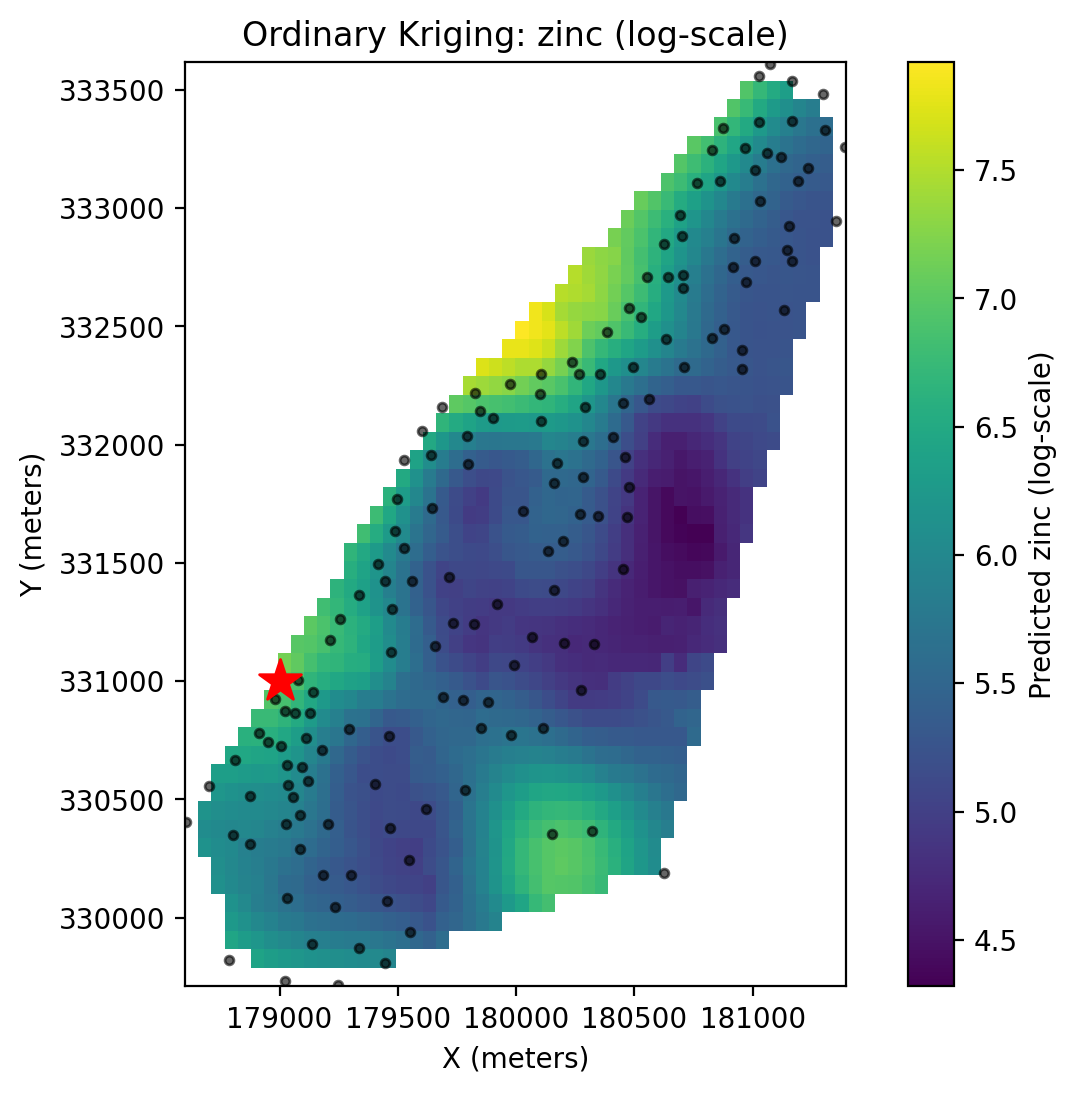

In [26]:
# Note: imshow with `extent` keeps the map in CRS coordinates, so the sample points overlay correctly
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(Z_masked, origin='lower', cmap='viridis',
               extent=[gx.min(), gx.max(), gy.min(), gy.max()])
gdf.plot(ax=ax, color='k', markersize=10, alpha=0.6)
ax.scatter(*x0, marker="*", s=250, color="red", zorder=4)   # our worked-example location
fig.colorbar(im, ax=ax, label=f'Predicted {TARGET} (log-scale)')
ax.set_title(f'Ordinary Kriging: {TARGET} (log-scale)')
ax.set_xlabel('X (meters)'); ax.set_ylabel('Y (meters)'); ax.set_aspect('equal')
plt.show()

### 8.11) Reading the map

The high-zinc ridge follows the river Meuse along the north-west edge — flood deposits, exactly the
process a geochemist would predict. The star marks our worked example; the map there reads ~6.96,
the number we solved by hand.

Now look at the printed ranges above, because they contradict a slogan you will hear: *"kriging
smooths"*. As a minimum-variance estimator it does compress the middle — the kriged interquartile
range (~5.17-6.17) is narrower than the observed one (~5.29-6.51) — but the predicted **extremes**
here (4.32 to 7.92) reach *outside* the observed values (4.73 to 7.52). That is the negative weights
of §8.5 at work near the edges, plus the Gaussian model's very smooth behaviour at the origin. For
a bounded or strictly positive quantity, that overshoot is a real hazard: always compare the
predicted range against the observed one, and if it matters, constrain the neighbourhood or use a
model that is less smooth at the origin (spherical, exponential).

What the map genuinely is *not* is a realistic-looking field: kriging returns the estimated mean
surface, not one plausible realisation of the phenomenon. If you need a surface with correct texture
(e.g. as input to a flow or exposure model), you want conditional **simulation**, not kriging —
see §9.

### 8.12) The other half of the output: the uncertainty map

Every prediction above came with a $\sigma$ that we have so far ignored. Mapping it is free, and it
is often the more useful of the two maps — it says where the next field campaign should go.

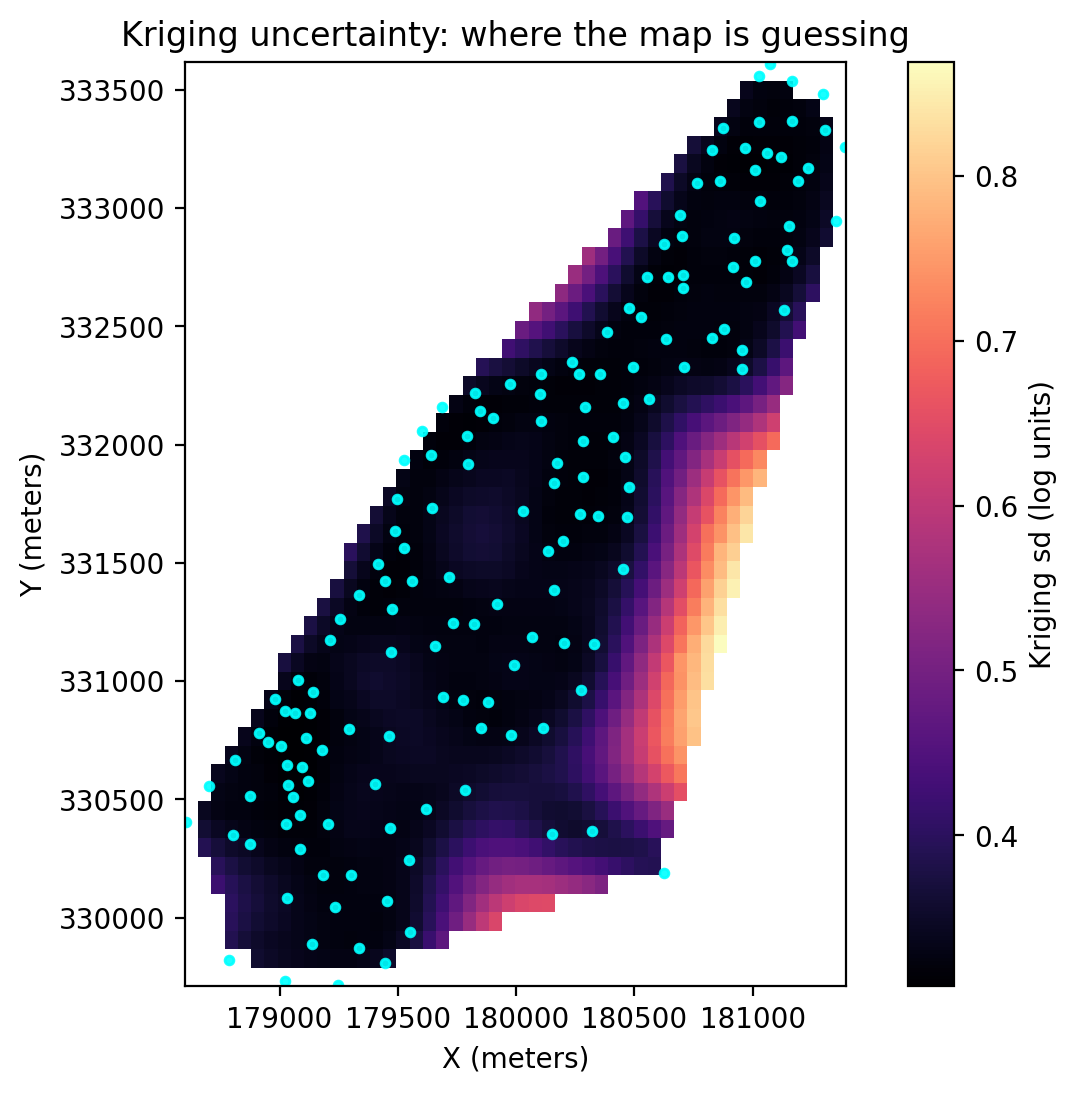

sd at sampled locations (dark)  ~ 0.31 log units
sd in the sparse gaps  (bright) ~ 0.87 log units


In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(SD_masked, origin='lower', cmap='magma',
               extent=[gx.min(), gx.max(), gy.min(), gy.max()])
gdf.plot(ax=ax, color='cyan', markersize=10, alpha=0.9)
fig.colorbar(im, ax=ax, label='Kriging sd (log units)')
ax.set_title('Kriging uncertainty: where the map is guessing')
ax.set_xlabel('X (meters)'); ax.set_ylabel('Y (meters)'); ax.set_aspect('equal')
plt.show()

print(f"sd at sampled locations (dark)  ~ {np.nanmin(SD_masked):.2f} log units")
print(f"sd in the sparse gaps  (bright) ~ {np.nanmax(SD_masked):.2f} log units")

The sd map is a picture of the **sampling design**, not of the zinc: it is dark wherever samples are
dense and bright in the gaps between transects, and it would look identical if every measurement
were reshuffled (recall §8.5 — no $Z$ appears in the variance formula). Where it is bright, the map
is interpolating between distant observations and you should not read local detail into it.

Two honest caveats to keep with the pretty picture:

- The kriging variance measures **geometry**, not truth. It does not know your variogram model is
  only a model, and it says nothing about a wrong range or a missed trend.
- With a nugget in the model, `skgstat`'s predictions at the sample locations are *not* exactly the
  observed values: $\gamma(0^{+})$ = nugget in the right-hand side, so the estimator filters what it
  regards as measurement noise. That is a defensible choice — but check the convention before
  claiming your map is an "exact interpolator".

**Lesson —** a prediction surface without its uncertainty surface is half a result; report where the
map is guessing, and let that decide where to sample next.

### 8.13) Transformations and back-transforms (note)

If you choose to transform the target (for example, to reduce skew), do that explicitly before
running the variogram and kriging cells and update the `values` array accordingly.

This notebook provides an optional natural-log transform in the data-cleaning cell: set
`LOG_TRANSFORM = True` to apply `np.log` to the target. The original values are saved to
`{TARGET}_orig` so you can back-transform predictions for interpretation.

Everything mapped above is on the **log scale**. Naively applying `np.exp` to a kriged log-mean
gives the *median*, not the mean, of the back-transformed distribution — it is biased low. The
correct move is a lognormal-kriging bias correction (which uses the kriging variance, another use
for §8.12) rather than a bare exponential. Apply transforms and then re-run the variogram/kriging
cells so derived objects (e.g., `V`, `ok`) reflect the transformed scale.

### 8.14) Recap: the whole method in six lines

1. Kriging predicts $\hat{Z}(x_0) = \sum_i w_i Z(x_i)$ — a weighted average, like every interpolator.
2. The weights come from the **fitted variogram**, so the data decide how far influence reaches.
3. $\mathbf{b}$ (neighbour-to-target semivariance) supplies **relevance**; $\mathbf{A}$
   (neighbour-to-neighbour semivariance) supplies **redundancy** — declustering for free.
4. Forcing $\sum_i w_i = 1$ (via the Lagrange multiplier $\mu$) buys **unbiasedness**; the
   minimisation buys **minimum variance**. Hence B.L.U.E.
5. The **kriging variance** depends only on geometry and the variogram — map it, and it tells you
   where to sample next.
6. A grid map is just steps 1-5 solved at every node.

**Lesson —** kriging turns a fitted variogram into a map with an error bar; the modelling effort
belongs in the variogram, because everything downstream is a linear solve that faithfully inherits
whatever you assumed there.


## 9) Summary & next steps

- **Moran's I**: global test for spatial autocorrelation in heavy metal concentrations.
- **Semivariogram**: reveals range (continuity scale), nugget (micro-scale + noise), sill (total variance).
- **Permutation envelope**: confirms structure stronger than random allocation.
- **Cross-validation**: shows predictive gain of kriging vs naive mean.
- **Ordinary Kriging**: turns the fitted variogram into weights — relevance from $\mathbf{b}$,
  declustering from $\mathbf{A}$, unbiasedness from $\sum_i w_i = 1$ — giving a predicted surface
  *and* a kriging-variance surface.

**Next steps**
- **Universal / Regression Kriging**: krige the residuals after modelling a trend in `elev`, `dist`
  or `om`, instead of assuming a locally constant mean (see notebook `09_spatial_ml_B_rfsp_kriging`).
- **Anisotropy**: the Meuse structure follows the river — fit directional variograms rather than one
  omnidirectional $\gamma(h)$.
- **Conditional simulation**: for surfaces with realistic texture rather than the smoothed mean.


### Best practices and tips

- Work in meters (Meuse already is).
- Check for skew; consider transforming heavy-tailed variables when justified (perform transformations explicitly before running the analysis).
- Inspect multiple metals: different processes → different ranges.
- Use permutation envelopes to avoid over-interpreting noise.
- Detrend with auxiliary variables (`elev`, `dist`, `om`) before modeling residual structure.
- Annotate nugget, sill, range for teaching clarity.
- Keep bin counts reasonable (10–18) and ensure ≥30 pairs per bin.